In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Smart_City_Complaints_1M_With_Missing_And_Duplicates (1).csv to Smart_City_Complaints_1M_With_Missing_And_Duplicates (1).csv


Phase 1: Data Understanding & Cleaning

In [ ]:
import pandas as pd

df = pd.read_csv("Smart_City_Complaints_1M_With_Missing_And_Duplicates (1).csv")

In [ ]:
df.head()

,Complaint_ID,Complaint_Date,Resolved_Date,Category,Department,Zone,Priority,Status,Citizen_Satisfaction
0,1,2025-02-02,2025-02-16,Water Supply,Sanitation,West,Medium,Resolved,4.0
1,2,2025-10-10,2025-10-21,Traffic Congestion,Drainage Dept,Central,Low,Resolved,1.0
2,3,2025-08-27,2025-09-12,Road Damage,Traffic Control,North,Low,Pending,5.0
3,4,2025-06-10,2025-06-11,Garbage Collection,Water Dept,East,Low,Pending,3.0
4,5,2025-06-08,2025-06-09,Water Supply,Roads Dept,North,Low,Resolved,NaN


In [ ]:
df.shape

(1000000, 9)

In [ ]:
df.isnull().sum()

,0
Complaint_ID,0
Complaint_Date,0
Resolved_Date,0
Category,10096
Department,10109
Zone,10088
Priority,0
Status,0
Citizen_Satisfaction,10097


In [ ]:
df.isnull().sum().sum()

np.int64(40390)

In [ ]:
df = df.dropna()

print(df.head())

   Complaint_ID Complaint_Date Resolved_Date            Category  \
0             1     2025-02-02    2025-02-16        Water Supply   
1             2     2025-10-10    2025-10-21  Traffic Congestion   
2             3     2025-08-27    2025-09-12         Road Damage   
3             4     2025-06-10    2025-06-11  Garbage Collection   
5             6     2025-11-10    2025-11-16       Public Safety   

        Department     Zone Priority    Status  Citizen_Satisfaction  
0       Sanitation     West   Medium  Resolved                   4.0  
1    Drainage Dept  Central      Low  Resolved                   1.0  
2  Traffic Control    North      Low   Pending                   5.0  
3       Water Dept     East      Low   Pending                   3.0  
5    Public Safety     West     High  Resolved                   3.0  


In [ ]:
df["Category"].fillna("Unknown", inplace=True)

/tmp/ipykernel_958/635108061.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Category"].fillna("Unknown", inplace=True)


In [ ]:
df["Citizen_Satisfaction"].fillna(
df["Citizen_Satisfaction"].mean(),
inplace=True
)

/tmp/ipykernel_958/3198482630.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Citizen_Satisfaction"].fillna(


In [ ]:
df.duplicated().sum()

np.int64(9616)

In [ ]:
df["Complaint_Date"] = pd.to_datetime(df["Complaint_Date"])

df["Resolved_Date"] = pd.to_datetime(df["Resolved_Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 960239 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Complaint_ID          960239 non-null  int64         
 1   Complaint_Date        960239 non-null  datetime64[ns]
 2   Resolved_Date         960239 non-null  datetime64[ns]
 3   Category              960239 non-null  object        
 4   Department            960239 non-null  object        
 5   Zone                  960239 non-null  object        
 6   Priority              960239 non-null  object        
 7   Status                960239 non-null  object        
 8   Citizen_Satisfaction  960239 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(1), object(5)
memory usage: 73.3+ MB


In [ ]:
df["Category"] = df["Category"].str.strip()
df["Category"] = df["Category"].str.lower()
print(df["Category"].head())

0          water supply
1    traffic congestion
2           road damage
3    garbage collection
5         public safety
Name: Category, dtype: object


Create Derived Variables

A. Resolution Delay

In [ ]:
df["Resolution_Delay"] = (
df["Resolved_Date"] -
df["Complaint_Date"]
).dt.days
df[["Complaint_Date","Resolved_Date","Resolution_Delay"]].head()

,Complaint_Date,Resolved_Date,Resolution_Delay
0,2025-02-02,2025-02-16,14
1,2025-10-10,2025-10-21,11
2,2025-08-27,2025-09-12,16
3,2025-06-10,2025-06-11,1
5,2025-11-10,2025-11-16,6


In [ ]:
severity_map = {
    "Low":1,
    "Medium":2,
    "High":3
}

df["Severity_Score"] = df["Priority"].map(severity_map)
df[["Priority", "Severity_Score"]].head(10)

,Priority,Severity_Score
0,Medium,2
1,Low,1
2,Low,1
3,Low,1
5,High,3
6,Low,1
7,Low,1
8,Low,1
9,Medium,2
10,Low,1


In [ ]:
df["Complaint_Date"] = pd.to_datetime(df["Complaint_Date"])
df["Month"] = df["Complaint_Date"].dt.month_name()
df[["Complaint_Date", "Month"]].head(10)

,Complaint_Date,Month
0,2025-02-02,February
1,2025-10-10,October
2,2025-08-27,August
3,2025-06-10,June
5,2025-11-10,November
6,2025-02-01,February
7,2025-09-12,September
8,2025-03-15,March
9,2025-02-04,February
10,2025-07-12,July


In [ ]:
df["Year"] = df["Complaint_Date"].dt.year
df[["Complaint_Date", "Year"]].head()

,Complaint_Date,Year
0,2025-02-02,2025
1,2025-10-10,2025
2,2025-08-27,2025
3,2025-06-10,2025
5,2025-11-10,2025


Phase 2: KPI Design   

In [ ]:
total_complaints = len(df)
print(total_complaints)

960239


In [ ]:
resolved_complaints = df[df["Status"]=="Resolved"].shape[0]

print(resolved_complaints)

816619


In [ ]:
resolution_rate = (
resolved_complaints / total_complaints
) * 100

print(resolution_rate)

85.04330692671303


In [ ]:
avg_resolution_time = df["Resolution_Delay"].mean()

print(avg_resolution_time)

9.99951053852218


In [ ]:
high_priority = df[
df["Priority"]=="High"
].shape[0]

print(high_priority)

144017


In [ ]:
satisfaction_score =(df["Citizen_Satisfaction"].mean())
satisfaction_score = round(df["Citizen_Satisfaction"].mean(), 2)

print(satisfaction_score)

3.0


In [ ]:
hotspot_zones = (
df["Zone"]
.value_counts()
)

print(hotspot_zones)

Zone
South      192272
East       192129
Central    192092
West       191891
North      191855
Name: count, dtype: int64


In [ ]:
dept_performance = (df.groupby("Department")["Status"].apply(lambda x:(x=="Resolved").mean()*100))

print(dept_performance)

Department
Drainage Dept      84.990615
Electrical         85.081570
Public Safety      85.092635
Roads Dept         85.158147
Sanitation         84.893083
Traffic Control    85.007977
Water Dept         85.079176
Name: Status, dtype: float64


Phase 3: Analytics Investigation

In [ ]:
zone_complaints = df["Zone"].value_counts()

print(zone_complaints)

Zone
South      192272
East       192129
Central    192092
West       191891
North      191855
Name: count, dtype: int64


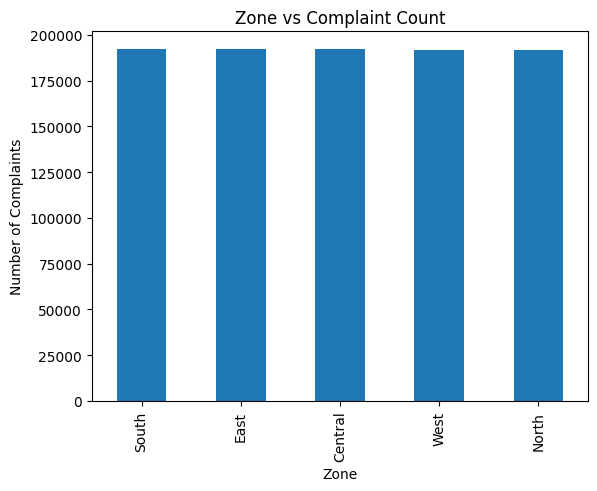

In [ ]:
import matplotlib.pyplot as plt

zone_complaints.plot(kind="bar")

plt.title("Zone vs Complaint Count")
plt.xlabel("Zone")
plt.ylabel("Number of Complaints")
plt.show()

In [ ]:
category_delay = df.groupby("Category")["Resolution_Delay"].mean()

print(category_delay)

Category
drainage problem        10.024371
garbage collection      10.008371
public safety           10.003114
road damage              9.984706
street light failure     9.974281
traffic congestion      10.013930
water supply             9.987793
Name: Resolution_Delay, dtype: float64


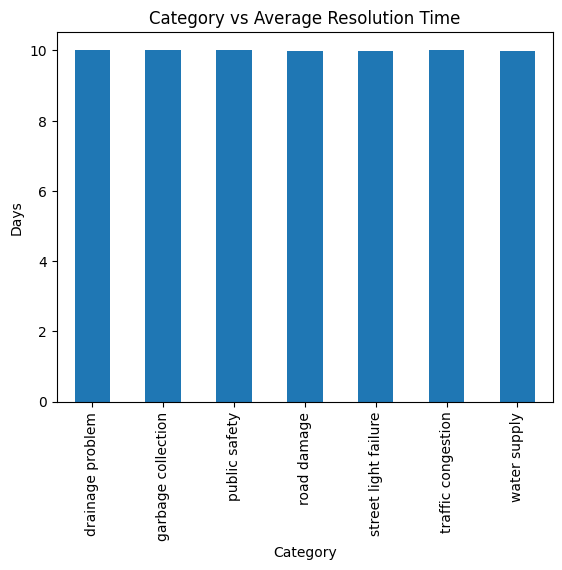

In [ ]:
category_delay.plot(kind="bar")

plt.title("Category vs Average Resolution Time")
plt.ylabel("Days")
plt.show()

In [ ]:
department_complaints = df.groupby("Department").size()

print(department_complaints)

Department
Drainage Dept      137454
Electrical         136938
Public Safety      137583
Roads Dept         136708
Sanitation         137116
Traffic Control    136646
Water Dept         137794
dtype: int64


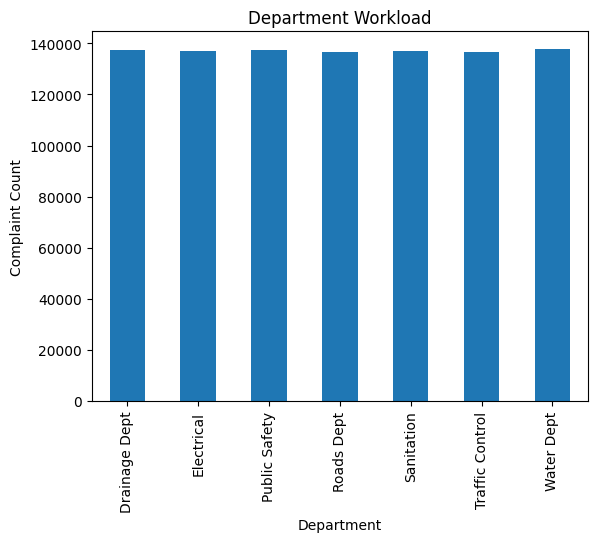

In [ ]:
department_complaints.plot(kind="bar")

plt.title("Department Workload")
plt.ylabel("Complaint Count")
plt.show()

In [ ]:
department_resolution = (
    df.groupby("Department")["Status"]
    .apply(lambda x: (x=="Resolved").mean()*100)
)

print(department_resolution)

Department
Drainage Dept      84.990615
Electrical         85.081570
Public Safety      85.092635
Roads Dept         85.158147
Sanitation         84.893083
Traffic Control    85.007977
Water Dept         85.079176
Name: Status, dtype: float64


In [ ]:
monthly_trend = df.groupby("Month").size()

print(monthly_trend)

Month
April        78909
August       81790
December     81318
February     73762
January      81567
July         81865
June         78896
March        81758
May          81540
November     78618
October      81408
September    78808
dtype: int64


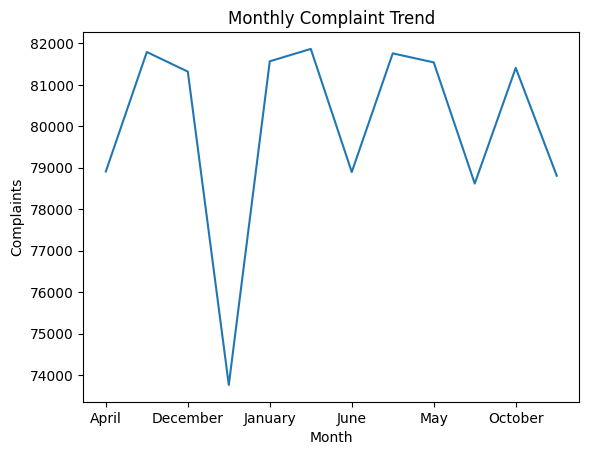

In [ ]:
monthly_trend.plot(kind="line")

plt.title("Monthly Complaint Trend")
plt.ylabel("Complaints")
plt.show()

In [ ]:
priority_delay = (
    df.groupby("Priority")["Resolution_Delay"]
    .mean()
)

print(priority_delay)

Priority
High       9.992063
Low       10.000734
Medium    10.000955
Name: Resolution_Delay, dtype: float64


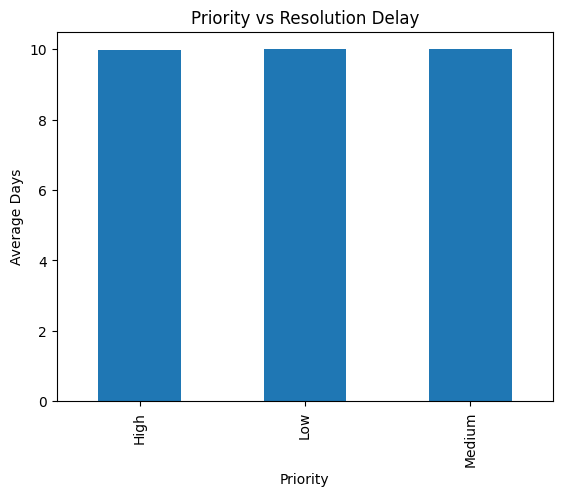

In [ ]:
priority_delay.plot(kind="bar")

plt.title("Priority vs Resolution Delay")
plt.ylabel("Average Days")
plt.show()

<Axes: xlabel='Priority', ylabel='Zone'>

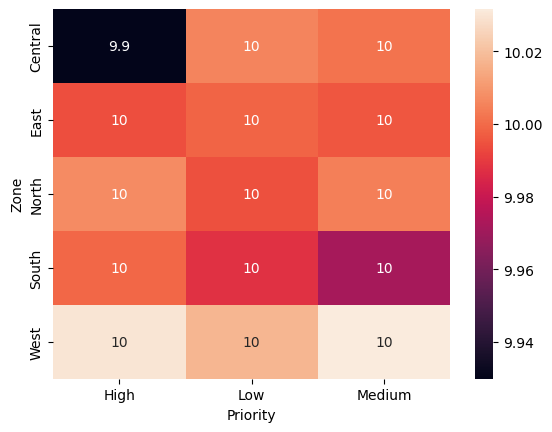

In [ ]:
import seaborn as sns

pivot = pd.pivot_table(
    df,
    values="Resolution_Delay",
    index="Zone",
    columns="Priority"
)

sns.heatmap(pivot, annot=True)

In [ ]:
df["Category"].value_counts()

,count
Category,
traffic congestion,137835
street light failure,137678
drainage problem,137338
water supply,137133
public safety,137109
road damage,136722
garbage collection,136424


In [ ]:
df["Zone"].value_counts()

,count
Zone,
South,192272
East,192129
Central,192092
West,191891
North,191855


In [ ]:
df.groupby("Department")["Resolution_Delay"].mean()

,Resolution_Delay
Department,
Drainage Dept,10.008083
Electrical,10.016986
Public Safety,10.003474
Roads Dept,9.993029
Sanitation,9.997630
Traffic Control,10.007948
Water Dept,9.969571
